# 02 — Relações entre as variáveis e a classificação do acidente

Este notebook responde a uma pergunta:

> **Quais variáveis mudam mais junto com a classificação do acidente?**

Vamos usar quatro ferramentas estatísticas, sempre com uma explicação antes do código:

1. **V de Cramér** — relação entre duas variáveis categóricas;
2. **intervalo de Wilson** — incerteza de uma porcentagem;
3. **Kruskal–Wallis e epsilon²** — diferença de uma variável numérica entre grupos;
4. **Spearman** — relação entre duas variáveis numéricas.

Não é necessário conhecer essas métricas antes de começar. A análise mostra **associações**, não causas. Uma variável associada a acidentes fatais não necessariamente causa a fatalidade.

## 1. Preparação

Usaremos bibliotecas prontas sempre que possível:

- `pandas` para tabelas;
- `seaborn` e `matplotlib` para gráficos;
- `scipy` para V de Cramér, qui-quadrado e Kruskal–Wallis;
- `statsmodels` para o intervalo de Wilson.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal
from scipy.stats.contingency import association
from statsmodels.stats.proportion import proportion_confint

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_rows", 30)

# Funciona ao abrir o notebook pela raiz do projeto ou pela pasta notebooks.
raiz = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
arquivo = raiz / "data" / "03_processed" / "acidentes_features.parquet"

## 2. Leitura dos dados

Cada linha representa um acidente. `classificacao_acidente` é a coluna que queremos entender e, mais tarde, prever. Ela será chamada de **alvo**.

In [2]:
dados = pd.read_parquet(arquivo)

alvo = "classificacao_acidente"
ordem_classes = [
    "sem vitimas",
    "com vitimas feridas",
    "com vitimas fatais",
]

print(f"Quantidade de acidentes: {len(dados):,}")
display(dados.head())

Quantidade de acidentes: 187,348


,dia_semana,br,fase_dia,condicao_meteorologica,tipo_pista,inclinacao,reta,km,volume_pedagio,icm,fator_humano,classificacao_acidente
0,quinta-feira,116,plena noite,chuva,dupla,nivelado,reta,59.9,1419025.0,<NA>,1,com vitimas fatais
1,quinta-feira,259,amanhecer,nublado,simples,nivelado,reta,12.8,<NA>,19.5,0,sem vitimas
2,quinta-feira,116,plena noite,ceu claro,simples,declive,curva,544.0,755787.0,<NA>,1,com vitimas feridas
3,quinta-feira,392,amanhecer,ceu claro,simples,nivelado,reta,102.4,119287.0,22.5,1,com vitimas feridas
4,quinta-feira,232,pleno dia,ceu claro,dupla,nivelado,reta,41.0,<NA>,<NA>,1,com vitimas feridas


## 3. Primeiro olhar para o alvo

Antes de comparar variáveis, precisamos saber quantos acidentes existem em cada classe. A coluna `percentual` é mais fácil de comparar que a contagem bruta.

,quantidade,percentual
classificacao_acidente,,
sem vitimas,29365,15.67
com vitimas feridas,144660,77.21
com vitimas fatais,13323,7.11


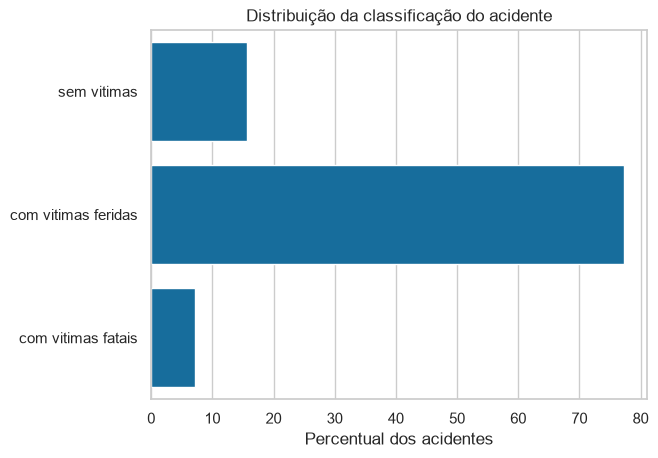

In [3]:
distribuicao = dados[alvo].value_counts().reindex(ordem_classes).to_frame("quantidade")
distribuicao["percentual"] = distribuicao["quantidade"] / len(dados) * 100

display(distribuicao.round(2))

sns.barplot(data=distribuicao.reset_index(), x="percentual", y=alvo)
plt.title("Distribuição da classificação do acidente")
plt.xlabel("Percentual dos acidentes")
plt.ylabel("")
plt.show()

## 4. Variáveis categóricas: V de Cramér

Uma variável categórica separa os dados em grupos. Exemplos: `tipo_pista` e `fase_dia`.

O **V de Cramér** resume quanto duas variáveis categóricas estão associadas:

- fica entre **0 e 1**;
- perto de **0**: pouca associação;
- quanto maior: mais a distribuição do alvo muda entre as categorias.

Também mostraremos o **valor-p** do teste qui-quadrado. Um valor-p abaixo de 0,05 indica evidência de associação, mas não diz se ela é forte. Com muitos dados, uma associação minúscula pode ter valor-p pequeno. Por isso, o ranking será feito pelo V de Cramér.

O código usa `pd.crosstab` para montar uma tabela de contagens e `scipy.stats.contingency.association` para calcular a métrica pronta.

In [4]:
categoricas = [
    "dia_semana",
    "br",
    "fase_dia",
    "condicao_meteorologica",
    "tipo_pista",
    "inclinacao",
    "reta",
    "fator_humano",
]

resultados_categoricos = []

for coluna in categoricas:
    tabela = pd.crosstab(dados[coluna].fillna("ausente"), dados[alvo])

    v = association(tabela, method="cramer")
    p_valor = chi2_contingency(tabela).pvalue

    resultados_categoricos.append(
        {"variavel": coluna, "cramers_v": v, "p_valor": p_valor}
    )

ranking_categoricas = pd.DataFrame(resultados_categoricos)
ranking_categoricas = ranking_categoricas.sort_values("cramers_v", ascending=False)

display(ranking_categoricas.round(4))

,variavel,cramers_v,p_valor
1,br,0.1165,0.0
7,fator_humano,0.1109,0.0
2,fase_dia,0.0902,0.0
4,tipo_pista,0.0728,0.0
0,dia_semana,0.0484,0.0
5,inclinacao,0.0323,0.0
3,condicao_meteorologica,0.0302,0.0
6,reta,0.0207,0.0


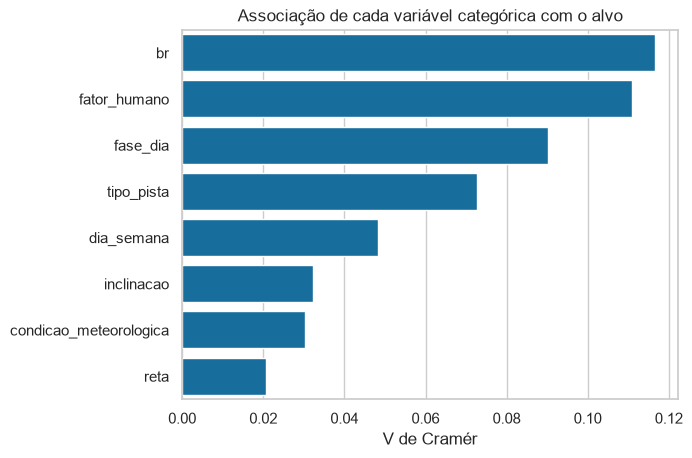

In [5]:
sns.barplot(data=ranking_categoricas, x="cramers_v", y="variavel")
plt.title("Associação de cada variável categórica com o alvo")
plt.xlabel("V de Cramér")
plt.ylabel("")
plt.show()

### 4.1 Associação entre as variáveis categóricas

Também podemos usar o V de Cramér para comparar as variáveis categóricas **entre si**. Isso ajuda a encontrar variáveis que podem carregar informações parecidas.

Na matriz abaixo:

- cada linha e cada coluna representam uma variável;
- valores próximos de 0 indicam pouca associação;
- valores maiores indicam associação mais forte;
- a diagonal vale 1 porque cada variável é comparada consigo mesma.

A variável `br` possui muitas categorias. Por isso, seus valores devem ser interpretados com mais cuidado. A matriz é uma ferramenta exploratória e não demonstra causalidade.

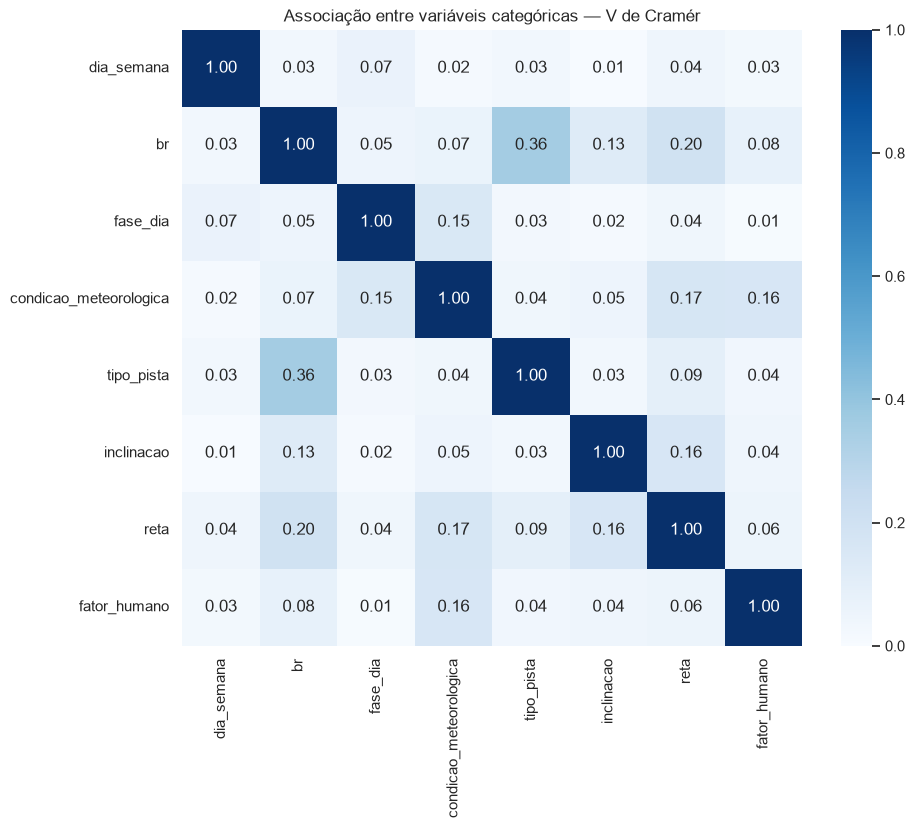

In [6]:
matriz_cramers = pd.DataFrame(index=categoricas, columns=categoricas, dtype=float)

for coluna_linha in categoricas:
    for coluna_coluna in categoricas:
        tabela = pd.crosstab(
            dados[coluna_linha].astype("string").fillna("ausente"),
            dados[coluna_coluna].astype("string").fillna("ausente"),
        )

        matriz_cramers.loc[coluna_linha, coluna_coluna] = association(
            tabela, method="cramer"
        )

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_cramers,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
)
plt.title("Associação entre variáveis categóricas — V de Cramér")
plt.show()

### Como ler os resultados

No ranking, a primeira linha tem a maior associação com o alvo **entre as variáveis testadas**. Na matriz, procure valores maiores fora da diagonal para encontrar variáveis que podem carregar informações parecidas. Isso não significa que uma variável prevê o alvo sozinha, nem que uma relação seja causal.

## 5. Uma porcentagem e sua incerteza: intervalo de Wilson

Agora calcularemos a porcentagem de acidentes fatais em cada tipo de pista.

Uma porcentagem calculada com poucos acidentes é incerta. O **intervalo de Wilson** cria uma faixa de valores plausíveis para essa porcentagem:

- faixa estreita: estimativa mais precisa;
- faixa larga: estimativa mais incerta.

Usaremos a função pronta `proportion_confint` do `statsmodels`. O intervalo não prova que um grupo é diferente de outro; ele apenas ajuda a não confiar demais em uma porcentagem isolada.

In [7]:
# True significa acidente fatal; False significa outra classificação.
dados["fatal"] = dados[alvo] == "com vitimas fatais"

resumo_pista = dados.groupby("tipo_pista")["fatal"].agg(["sum", "count"])
resumo_pista = resumo_pista.rename(columns={"sum": "fatais", "count": "total"})
resumo_pista["taxa_fatal"] = resumo_pista["fatais"] / resumo_pista["total"]

limites_inferiores = []
limites_superiores = []

for _, linha in resumo_pista.iterrows():
    inferior, superior = proportion_confint(
        count=linha["fatais"],
        nobs=linha["total"],
        alpha=0.05,
        method="wilson",
    )
    limites_inferiores.append(inferior)
    limites_superiores.append(superior)

resumo_pista["ic95_inferior"] = limites_inferiores
resumo_pista["ic95_superior"] = limites_superiores

# Multiplicamos por 100 apenas para exibir como porcentagem.
colunas_percentuais = ["taxa_fatal", "ic95_inferior", "ic95_superior"]
resumo_pista[colunas_percentuais] = resumo_pista[colunas_percentuais] * 100

display(resumo_pista.sort_values("taxa_fatal", ascending=False).round(2))

,fatais,total,taxa_fatal,ic95_inferior,ic95_superior
tipo_pista,,,,,
simples,8824,90142,9.79,9.60,9.98
dupla,3763,79205,4.75,4.60,4.90
multipla,736,18001,4.09,3.81,4.39


## 6. Variáveis numéricas: Kruskal–Wallis e epsilon²

`km`, `volume_pedagio` e `icm` são variáveis numéricas.

O teste de **Kruskal–Wallis** compara os valores de uma variável numérica entre as três classes de acidente. Ele responde: “há evidência de que pelo menos uma classe tem distribuição diferente?”

- valor-p abaixo de 0,05: há evidência de alguma diferença;
- o teste não informa se a diferença é grande.

Para medir o tamanho da diferença, usamos **epsilon²**:

- próximo de 0: os grupos são muito parecidos nessa variável;
- quanto maior: maior a separação entre os grupos.

O SciPy calcula o Kruskal–Wallis. Como ele não entrega epsilon² diretamente, fazemos a conversão em uma linha com a fórmula `(H - k + 1) / (n - k)`, onde `H` vem do teste, `k` é o número de grupos e `n` é o número de valores usados.

In [8]:
numericas = ["km", "volume_pedagio", "icm"]
resultados_numericos = []

for coluna in numericas:
    grupos = []

    for classe in ordem_classes:
        valores = dados.loc[dados[alvo] == classe, coluna].dropna()
        grupos.append(valores)

    teste = kruskal(*grupos)
    n = sum(len(grupo) for grupo in grupos)
    k = len(grupos)
    epsilon2 = max(0, (teste.statistic - k + 1) / (n - k))

    resultados_numericos.append(
        {
            "variavel": coluna,
            "epsilon2": epsilon2,
            "p_valor": teste.pvalue,
            "valores_usados": n,
        }
    )

ranking_numericas = pd.DataFrame(resultados_numericos)
ranking_numericas = ranking_numericas.sort_values("epsilon2", ascending=False)

display(ranking_numericas.round(4))

,variavel,epsilon2,p_valor,valores_usados
1,volume_pedagio,0.0038,0.0,110020
0,km,0.0008,0.0,187348
2,icm,0.0002,0.0,110381


In [9]:
# As medianas ajudam a entender a direção das diferenças encontradas pelo teste.
medianas = dados.groupby(alvo)[numericas].median().reindex(ordem_classes)
display(medianas.round(2))

,km,volume_pedagio,icm
classificacao_acidente,,,
sem vitimas,194.0,313759.0,18.0
com vitimas feridas,188.1,363862.0,18.25
com vitimas fatais,216.0,279562.0,17.75


### Como ler o resultado

Olhe primeiro para `epsilon2`, que mostra o tamanho da diferença. Depois use as medianas para entender os valores típicos de cada classe. O valor-p sozinho não deve ser usado para chamar uma variável de importante.

## 7. Relação entre variáveis numéricas: Spearman

A correlação de **Spearman** verifica se duas variáveis tendem a crescer ou diminuir juntas, sem exigir uma relação em linha reta.

- perto de **1**: quando uma cresce, a outra tende a crescer;
- perto de **-1**: quando uma cresce, a outra tende a diminuir;
- perto de **0**: não há uma tendência monotônica forte.

Correlação não é causalidade. Usaremos o método pronto `corr(method="spearman")` do pandas.

,km,volume_pedagio,icm
km,1.000,-0.140,0.037
volume_pedagio,-0.140,1.000,0.079
icm,0.037,0.079,1.000


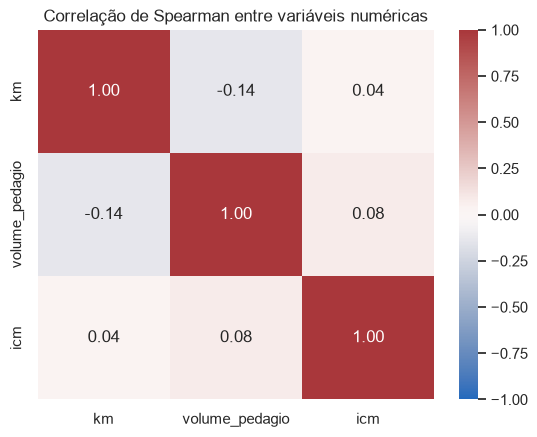

In [10]:
correlacao_spearman = dados[numericas].corr(method="spearman")
display(correlacao_spearman.round(3))

sns.heatmap(
    correlacao_spearman,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
)
plt.title("Correlação de Spearman entre variáveis numéricas")
plt.show()

## 8. Resumo automático

A célula abaixo mostra os principais resultados sem fixar números no texto. Assim, o resumo continua correto caso os dados mudem.

In [11]:
melhor_categorica = ranking_categoricas.iloc[0]
melhor_numerica = ranking_numericas.iloc[0]

print(
    f"Maior V de Cramér: {melhor_categorica['variavel']} "
    f"(V = {melhor_categorica['cramers_v']:.3f})."
)
print(
    f"Maior epsilon²: {melhor_numerica['variavel']} "
    f"(epsilon² = {melhor_numerica['epsilon2']:.4f})."
)
print("Use a tabela de Spearman acima para comparar cada par de variáveis numéricas.")

Maior V de Cramér: br (V = 0.116).
Maior epsilon²: volume_pedagio (epsilon² = 0.0038).
Use a tabela de Spearman acima para comparar cada par de variáveis numéricas.


## Conclusão

Use esta ordem para interpretar os resultados:

1. veja o **V de Cramér** para comparar variáveis categóricas;
2. veja a taxa e o **intervalo de Wilson** para não ignorar a incerteza;
3. veja o **epsilon²** antes do valor-p nas variáveis numéricas;
4. use **Spearman** para identificar variáveis numéricas que carregam informação parecida.

Essas métricas ajudam a encontrar padrões e escolher o que investigar na modelagem. Elas não demonstram que uma variável causa um tipo de acidente.